In [1]:
import os

os.chdir('..')
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"   # set for determinism

   Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [2]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
import src.loss.SDF_loss as loss
from src.mesh_extraction.marching_cubes_test import write_obj
import src.model.MLP as simple
import src.data.dataset as data
import src.model.pruning_module as pm
from src.model.training import iou
import src.mesh_extraction.marching_cubes_gpu as marching_cubes
import random
from src.model.metrics import chamfer_hausdorff

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
def set_seeds():
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

mesh = data.MeshDataset('data/pointclouds/bunny/Stanford_bunny.ply')
gt_points = torch.from_numpy(np.asarray(mesh.mesh.sample_points_uniformly(number_of_points=50000).points).astype(np.float32)).to(torch.device("cuda")).requires_grad_(True)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [3]:
size_per_layer = 256
set_seeds()
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

## Model training without pruning or densification



Step 0 | IoU 0.2404 | Loss 45.0091
Step 10 | Loss 7.4674
Step 20 | Loss 3.1888
Step 30 | Loss 2.2664
Step 40 | Loss 1.6742
Step 50 | Loss 1.3604
Step 60 | Loss 1.1206
Step 70 | Loss 0.9957
Step 80 | Loss 0.9035
Step 90 | Loss 0.8188
Step 100 | IoU 0.8183 | Loss 0.7507
Step 110 | Loss 0.6861
Step 120 | Loss 0.6248
Step 130 | Loss 0.5747
Step 140 | Loss 0.5487
Step 150 | Loss 0.4962
Step 160 | Loss 0.4875
Step 170 | Loss 0.4417
Step 180 | Loss 0.4336
Step 190 | Loss 0.4087
Step 200 | IoU 0.9793 | Loss 0.3841
Step 210 | Loss 0.3684
Step 220 | Loss 0.3481
Step 230 | Loss 0.3293
Step 240 | Loss 0.3434
Step 250 | Loss 0.3014
Step 260 | Loss 0.3267
Step 270 | Loss 0.3001
Step 280 | Loss 0.2892
Step 290 | Loss 0.2800
Step 300 | IoU 0.9912 | Loss 0.2604
Step 310 | Loss 0.2569
Step 320 | Loss 0.2712
Step 330 | Loss 0.2682
Step 340 | Loss 0.2613
Step 350 | Loss 0.2803
Step 360 | Loss 0.2494
Step 370 | Loss 0.2537
Step 380 | Loss 0.2382
Step 390 | Loss 0.2424
Step 400 | IoU 0.9918 | Loss 0.2355
St

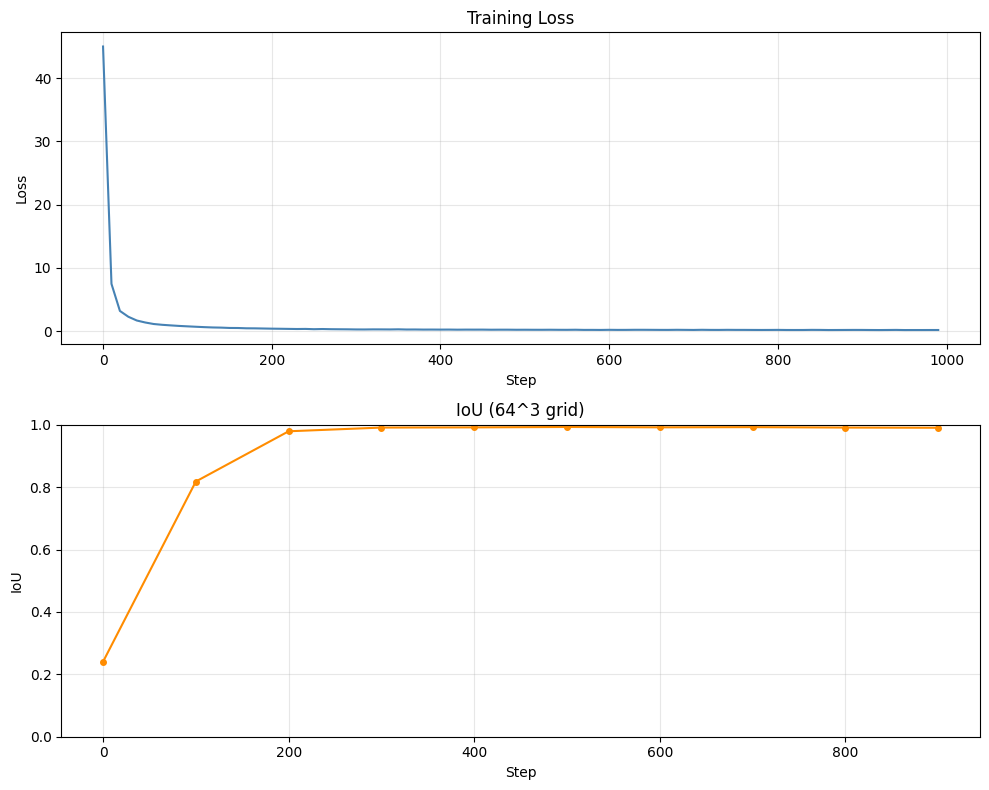

Saved training_curves.png


In [4]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene)
np.savez(
    "bunny_weights/history/large_unpruned_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/large_unpruned.pth")

## Model size

In [5]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Final layer    :    1 neurons


In [6]:
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/large_unpruned.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
#marching_cubes.write_obj("bunny_128_unpruned_large.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/1451948590.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/large_unpruned.pth",

In [7]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_unpruned_large.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0014 | hausdorff: 0.0245


## Model training with densification

In [ ]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[1102, 256, 256])
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.2385 | Loss 44.8964
Step 10 | Loss 8.0230
Step 20 | Loss 4.1725
Step 30 | Loss 2.6017
Step 40 | Loss 1.9408
Step 50 | Loss 1.6190
Step 60 | Loss 1.4383
Step 70 | Loss 1.2754
Step 80 | Loss 1.1370
Step 90 | Loss 1.0795
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

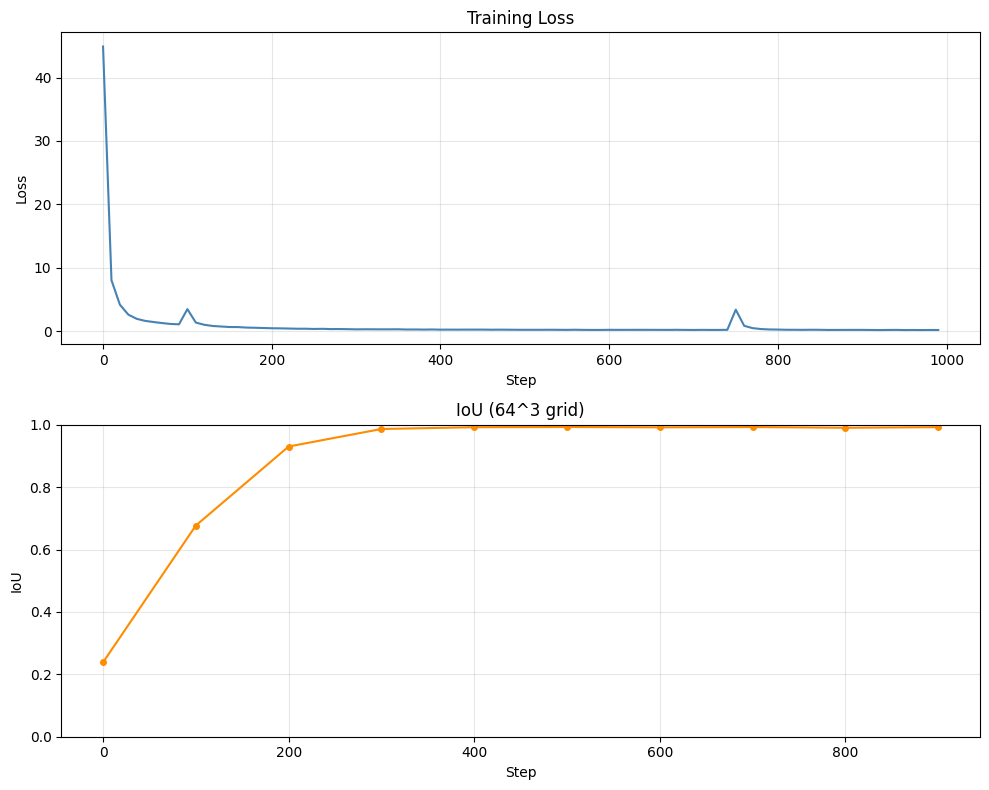

Saved training_curves.png


In [9]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, densification=True)
np.savez(
    "bunny_weights/history/densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/densified.pth")

In [10]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Final layer    :    1 neurons


In [11]:
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("bunny_128_densified.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/3757915327.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/densified.pth", map_

In [12]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_densified.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0012 | hausdorff: 0.0282


## AIRe: Model training (no densification)

In [57]:
set_seeds()
size_per_layer = 256
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
prune_AIRe = pm.AIRe(model, 0.6)
model_loss = loss.Loss(lambda_surface=175, lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.2404 | Loss 45.0091
Step 10 | Loss 7.4674
Step 20 | Loss 3.1888
Step 30 | Loss 2.2664
Step 40 | Loss 1.6742
Step 50 | Loss 1.3604
Step 60 | Loss 1.1206
Step 70 | Loss 0.9957
Step 80 | Loss 0.9035
Step 90 | Loss 0.8188
Step 100 | IoU 0.8183 | Loss 0.7507
Step 110 | Loss 0.6861
Step 120 | Loss 0.6248
Step 130 | Loss 0.5747
Step 140 | Loss 0.5487
Step 150 | Loss 0.4962
Step 160 | Loss 0.4875
Step 170 | Loss 0.4417
Step 180 | Loss 0.4336
Step 190 | Loss 0.4087
TWD is now applied
Step 200 | IoU 0.9793 | Loss 0.3841
Step 210 | Loss 4.1321
Step 220 | Loss 7.6765
Step 230 | Loss 9.6400
Step 240 | Loss 9.6357
Step 250 | Loss 8.0883
Step 260 | Loss 6.1289
Step 270 | Loss 4.4649
Step 280 | Loss 3.2821
Step 290 | Loss 2.4708
Step 300 | IoU 0.9753 | Loss 1.9953
Step 310 | Loss 1.7502
Step 320 | Loss 1.6265
Step 330 | Loss 1.5763
Step 340 | Loss 1.5847
Step 350 | Loss 1.6317
Step 360 | Loss 1.6390
Step 370 | Loss 1.6890
Step 380 | Loss 1.7393
Step 390 | Loss 1.8207
Step 400 | IoU 0.98

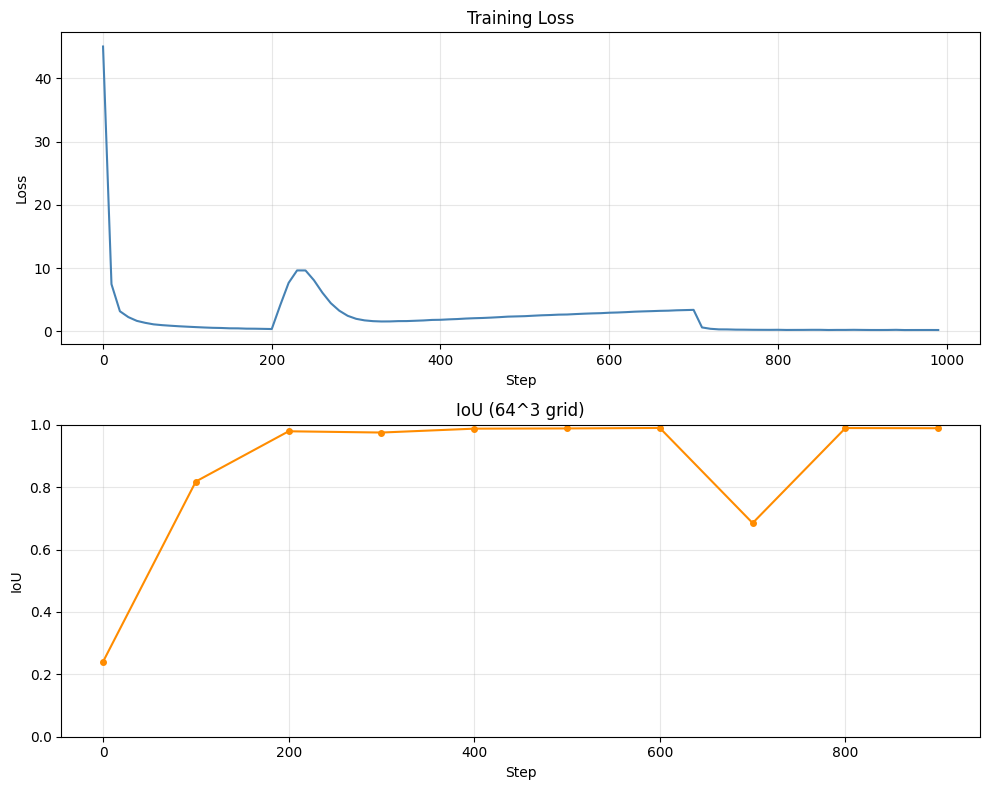

Saved training_curves.png


In [58]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe)
np.savez(
    "bunny_weights/history/AIRe_0.6_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/AIRe_0.6.pth")

In [37]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:   52 neurons
Hidden layer  2:   52 neurons
Final layer    :    1 neurons


In [59]:
model = si.SIRENSDF(hidden_dims=[256, 103, 103])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/AIRe_0.6.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("bunny_128_AIRe_0.6.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/4014372696.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/AIRe_0.6.pth", map_l

In [60]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_AIRe_0.6.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0017 | hausdorff: 0.0277


## DepGraph: Model training (no densification)

In [61]:
set_seeds()
device = torch.device("cuda")
model = si.SIRENSDF(hidden_dims=[256, 256, 256]).to(device)
prune_DepGraph = pm.DepGraph(model, 0.6)
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.2404 | Loss 45.0091
Step 10 | Loss 7.4674
Step 20 | Loss 3.1888
Step 30 | Loss 2.2664
Step 40 | Loss 1.6742
Step 50 | Loss 1.3604
Step 60 | Loss 1.1206
Step 70 | Loss 0.9957
Step 80 | Loss 0.9035
Step 90 | Loss 0.8188
Step 100 | IoU 0.8183 | Loss 0.7507
Step 110 | Loss 0.6861
Step 120 | Loss 0.6248
Step 130 | Loss 0.5747
Step 140 | Loss 0.5487
Step 150 | Loss 0.4962
Step 160 | Loss 0.4875
Step 170 | Loss 0.4417
Step 180 | Loss 0.4336
Step 190 | Loss 0.4087
TWD is now applied
Step 200 | IoU 0.9793 | Loss 0.3841
Step 210 | Loss 0.3684
Step 220 | Loss 0.3481
Step 230 | Loss 0.3293
Step 240 | Loss 0.3434
Step 250 | Loss 0.3014
Step 260 | Loss 0.3267
Step 270 | Loss 0.3001
Step 280 | Loss 0.2892
Step 290 | Loss 0.2800
Step 300 | IoU 0.9912 | Loss 0.2604
Step 310 | Loss 0.2569
Step 320 | Loss 0.2712
Step 330 | Loss 0.2682
Step 340 | Loss 0.2613
Step 350 | Loss 0.2803
Step 360 | Loss 0.2494
Step 370 | Loss 0.2537
Step 380 | Loss 0.2382
Step 390 | Loss 0.2424
Step 400 | IoU 0.99

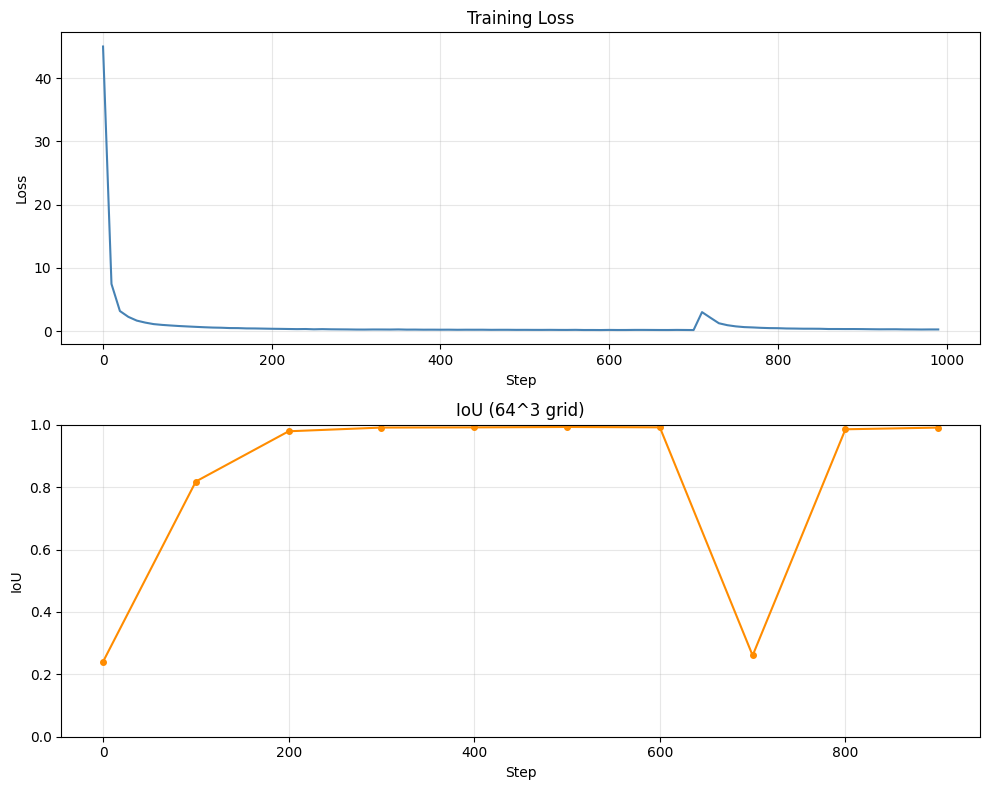

Saved training_curves.png


In [62]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph)
np.savez(
    "bunny_weights/history/DepGraph_0.6_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/DepGraph_0.6.pth")

In [63]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Final layer    :    1 neurons


In [64]:
model = si.SIRENSDF(hidden_dims=[256, 102, 102])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/DepGraph_0.6.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("bunny_128_DepGraph_0.6.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/525654753.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/DepGraph_0.6.pth", ma

In [65]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_DepGraph_0.6.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0015 | hausdorff: 0.0247


## AIRe: Model training with densification

In [78]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[151, 256, 256])
prune_AIRe = pm.AIRe(model, 0.6)
model_loss = loss.Loss(lambda_surface=175, lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.2385 | Loss 44.8964
Step 10 | Loss 8.0230
Step 20 | Loss 4.1725
Step 30 | Loss 2.6017
Step 40 | Loss 1.9408
Step 50 | Loss 1.6190
Step 60 | Loss 1.4383
Step 70 | Loss 1.2754
Step 80 | Loss 1.1370
Step 90 | Loss 1.0795
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

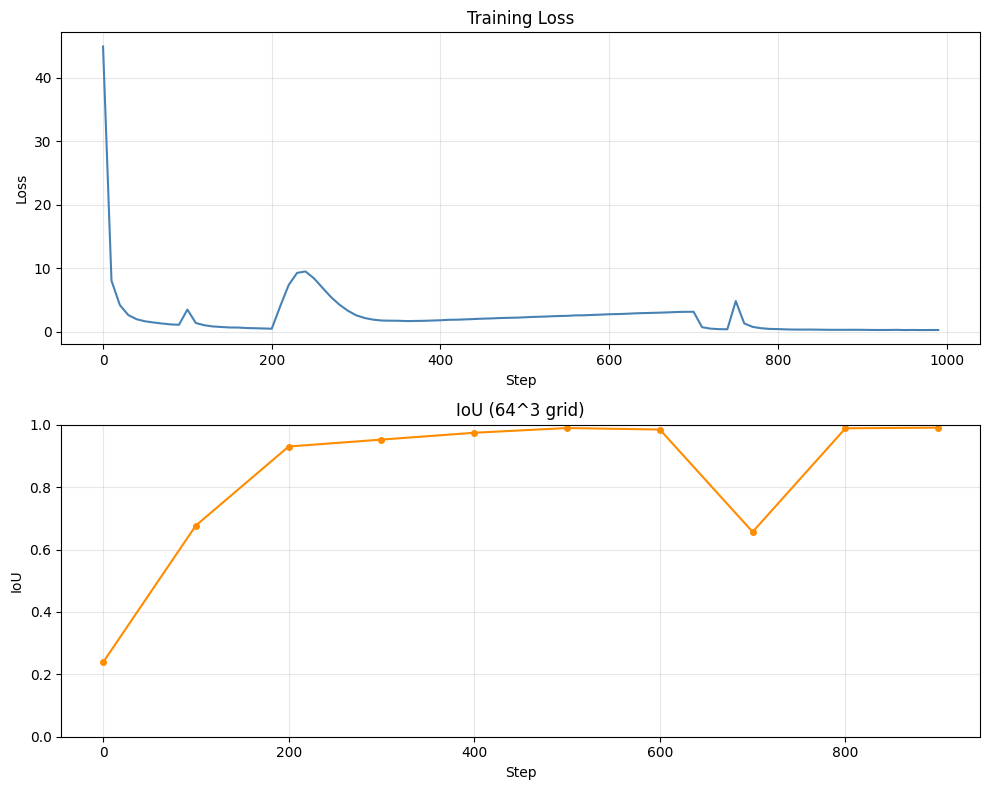

Saved training_curves.png


In [79]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe, densification=True)
np.savez(
    "bunny_weights/history/AIRe_0.6_densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/AIRe_0.6_densified.pth")

In [80]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  103 neurons
Hidden layer  2:  103 neurons
Final layer    :    1 neurons


In [81]:
model = si.SIRENSDF(hidden_dims=[256, 103, 103])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/AIRe_0.6_densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("bunny_128_AIRe_0.6_densified.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/2930684377.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/AIRe_0.6_densified.p

In [82]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_AIRe_0.6_densified.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0016 | hausdorff: 0.0266


## DepGraph: Model training with densification

In [71]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[151, 256, 256]).to(torch.device("cuda"))
prune_DepGraph = pm.DepGraph(model, 0.6)
model_loss = loss.Loss(lambda_surface=175, lambda_eikonal=20, lambda_normal=15, lambda_inter=10, lambda_off=15, model=model, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.2385 | Loss 44.8964
Step 10 | Loss 8.0230
Step 20 | Loss 4.1725
Step 30 | Loss 2.6017
Step 40 | Loss 1.9408
Step 50 | Loss 1.6190
Step 60 | Loss 1.4383
Step 70 | Loss 1.2754
Step 80 | Loss 1.1370
Step 90 | Loss 1.0795
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

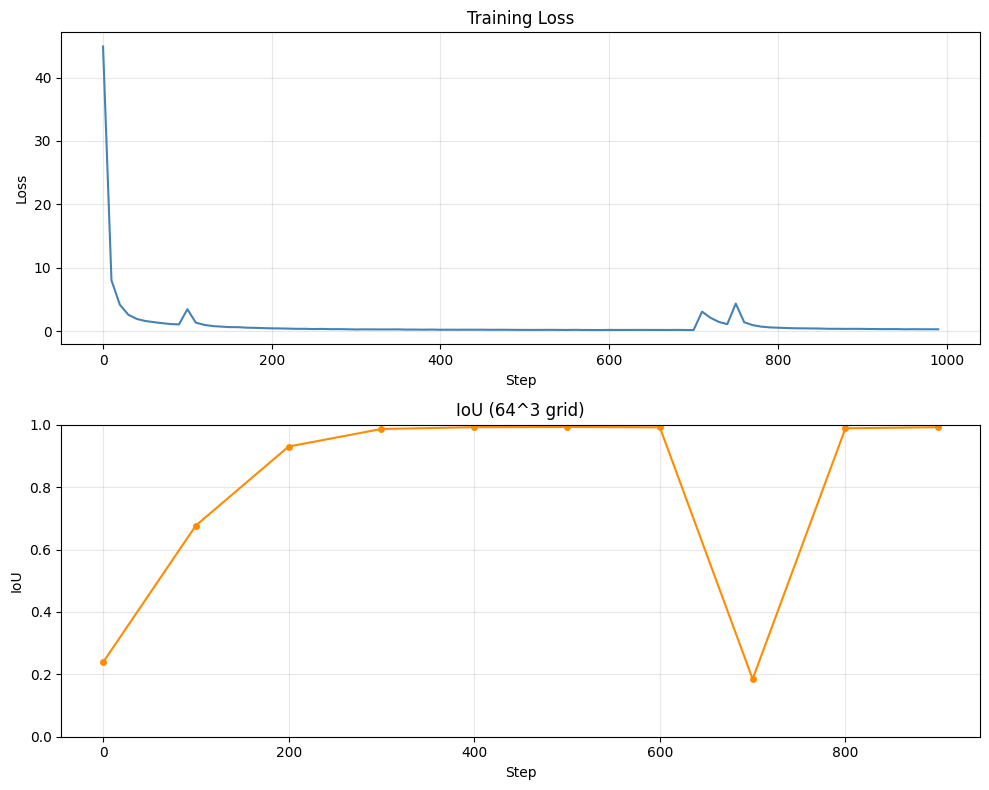

Saved training_curves.png


In [72]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph, densification=True)
np.savez(
    "bunny_weights/history/DepGraph_0.6_densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "bunny_weights/DepGraph_0.6_densified.pth")

In [73]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Final layer    :    1 neurons


In [74]:
model = si.SIRENSDF(hidden_dims=[256, 102, 102])
missing, unexpected = model.load_state_dict(torch.load("bunny_weights/DepGraph_0.6_densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("bunny_128_DepGraph_0.6_densified.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_8991/1252226793.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("bunny_weights/DepGraph_0.6_densifi

In [75]:
chamfer, hausdorff = chamfer_hausdorff(mesh, model, "bunny_128_DepGraph_0.6_densified.obj", gt_points)
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

chamfer: 0.0014 | hausdorff: 0.0277


In [3]:
surfaces = ["dragon", "bunny"]
ratios = ["0.4", "0.6", "0.8"]
sizes = [154, 103, 52]
device = torch.device("cuda")
for i in surfaces:
    print(f"IoU's for {i}:")

    mesh = data.MeshDataset(f'data/pointclouds/{i}/Stanford_{i}.ply')
    print("mesh loaded!")

    with torch.no_grad():
        x = torch.linspace(-1, 1, 256)
        y = torch.linspace(-1, 1, 256)
        z = torch.linspace(-1, 1, 256)

        grid = torch.stack(torch.meshgrid(x, y, z, indexing='ij'), dim=-1).reshape(-1,3)
        grid_o3d = o3d.core.Tensor(grid.numpy(), dtype=o3d.core.Dtype.Float32)
        grid_sdf = mesh.scene.compute_signed_distance(grid_o3d).numpy()
        grid_mask = torch.tensor(grid_sdf < 0, dtype=torch.bool)

    model = si.SIRENSDF(hidden_dims=[256, 256, 256]).to(torch.device("cuda"))
    missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/large_unpruned.pth", map_location=device, weights_only=True))
    metric = iou(model, grid_mask, grid)
    print(f"    baseline {metric:.4f}")

    missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/densified.pth", map_location=device, weights_only=True))
    metric = iou(model, grid_mask, grid)
    print(f"    densified {metric:.4f}")

    for j in range(3):
        print(f"    {ratios[j]} pruning ratio:")
        print(f"        AIRe:")

        model = si.SIRENSDF(hidden_dims=[256, sizes[j], sizes[j]]).to(torch.device("cuda"))
        missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/AIRe_{ratios[j]}.pth", map_location=device, weights_only=True))
        metric = iou(model, grid_mask, grid)

        print(f"            normal {metric:.4f}")

        missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/AIRe_{ratios[j]}_densified.pth", map_location=device, weights_only=True))
        metric = iou(model, grid_mask, grid)
        print(f"            densified {metric:.4f}")

        print(f"        DepGraph:")

        model = si.SIRENSDF(hidden_dims=[256, sizes[j] - 1, sizes[j] - 1]).to(torch.device("cuda"))
        missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/DepGraph_{ratios[j]}.pth", map_location=device, weights_only=True))
        metric = iou(model, grid_mask, grid)

        print(f"            normal {metric:.4f}")

        missing, unexpected = model.load_state_dict(torch.load(f"{i}_weights/DepGraph_{ratios[j]}_densified.pth", map_location=device, weights_only=True))
        metric = iou(model, grid_mask, grid)
        print(f"            densified {metric:.4f}")

IoU's for dragon:
mesh loaded!
    baseline 0.9416
    densified 0.9473
    0.4 pruning ratio:
        AIRe:
            normal 0.9405
            densified 0.9487
        DepGraph:
            normal 0.9392
            densified 0.9448
    0.6 pruning ratio:
        AIRe:
            normal 0.9367
            densified 0.9420
        DepGraph:
            normal 0.9377
            densified 0.9468
    0.8 pruning ratio:
        AIRe:
            normal 0.9266
            densified 0.9449
        DepGraph:
            normal 0.9222
            densified 0.9253
IoU's for bunny:
mesh loaded!
    baseline 0.9914
    densified 0.9928
    0.4 pruning ratio:
        AIRe:
            normal 0.9898
            densified 0.9913
        DepGraph:
            normal 0.9911
            densified 0.9925
    0.6 pruning ratio:
        AIRe:
            normal 0.9900
            densified 0.9902
        DepGraph:
            normal 0.9909
            densified 0.9915
    0.8 pruning ratio:
        A

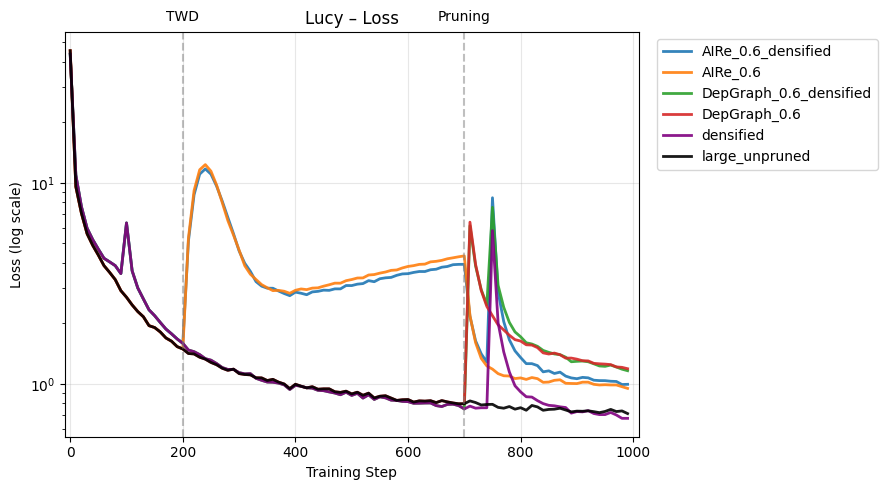

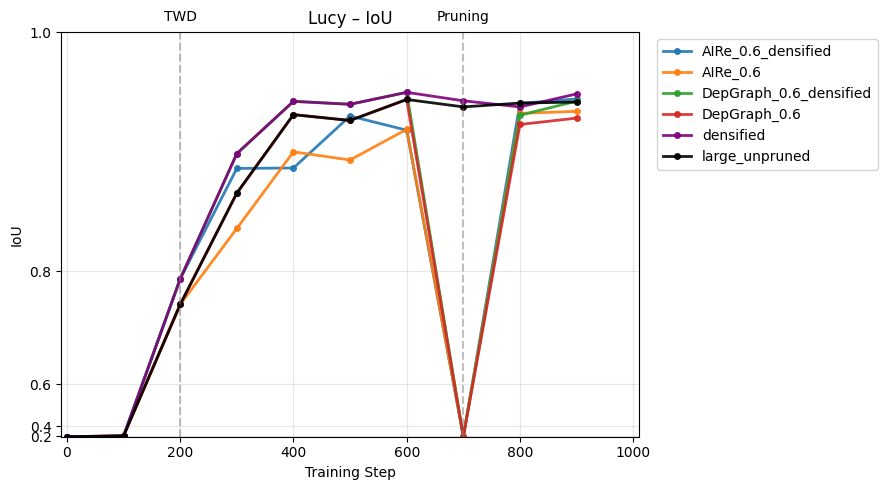

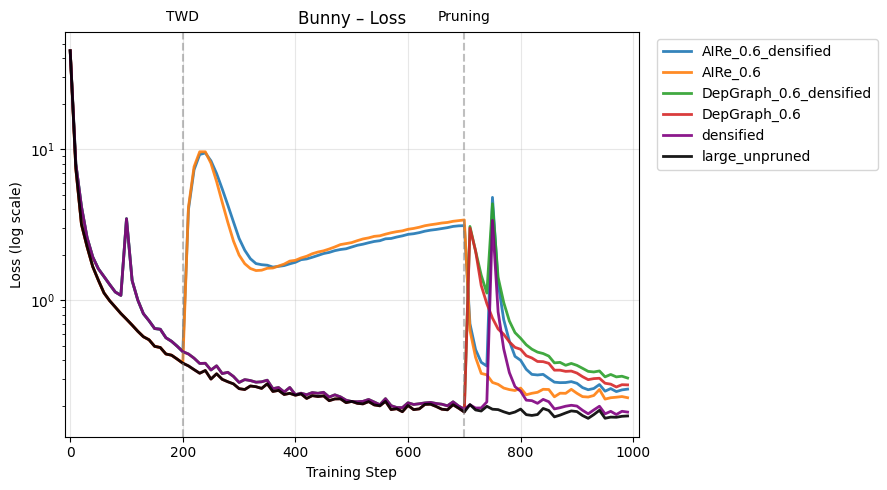

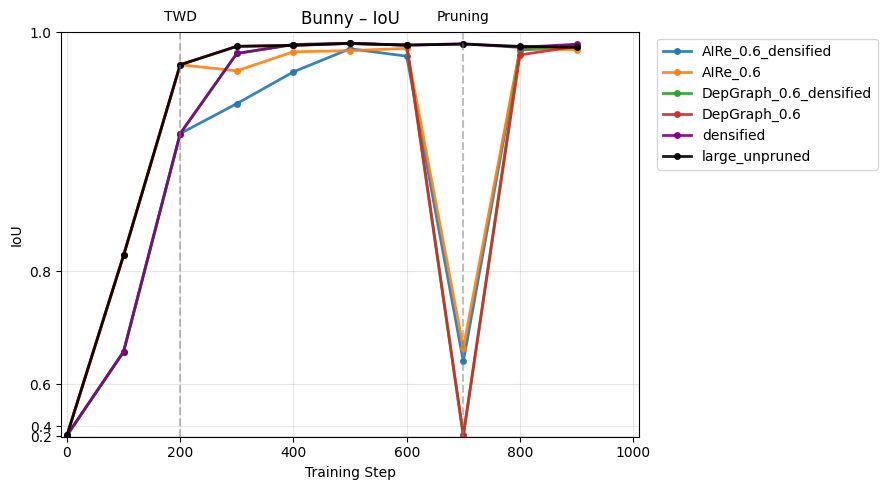

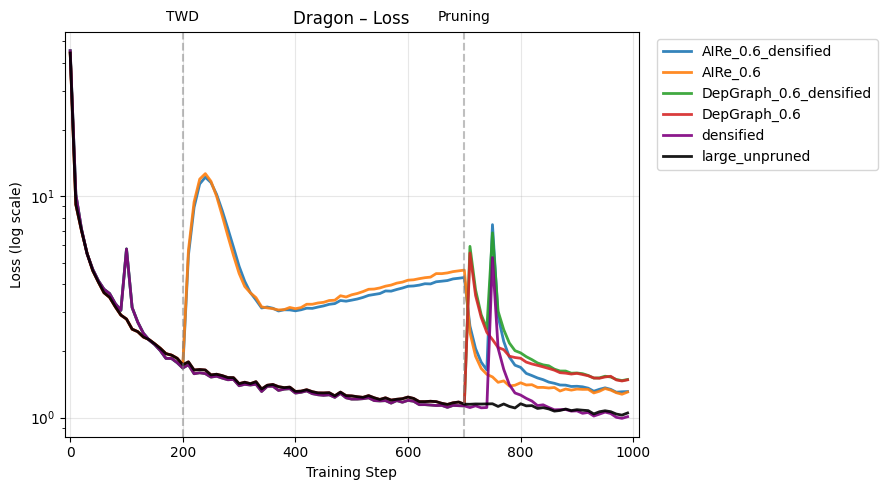

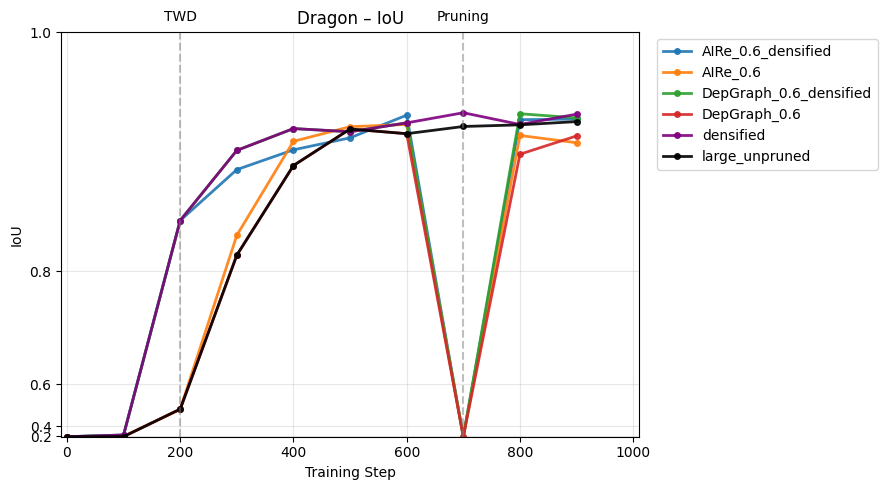

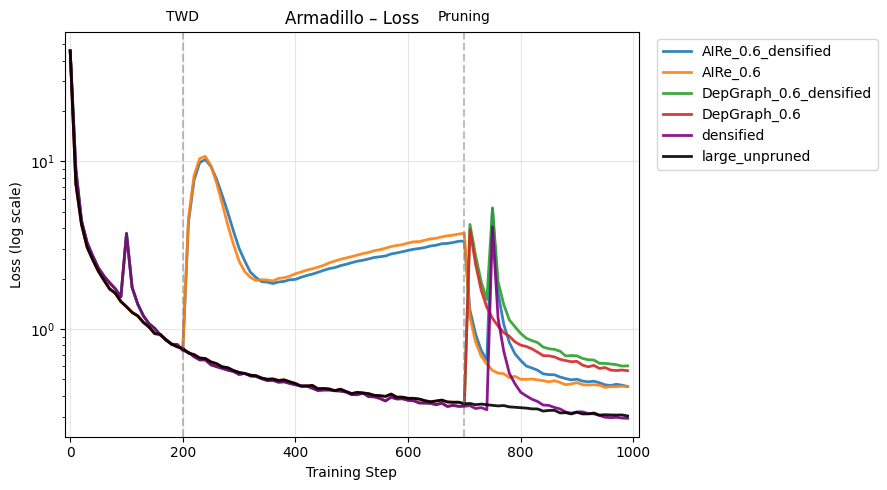

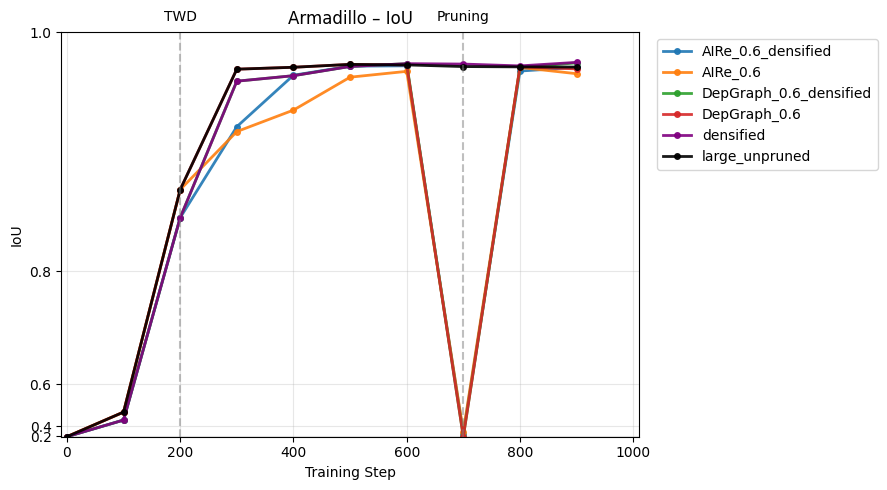

In [3]:
from plot import plot_histories

plot_histories("lucy")
plot_histories("bunny")
plot_histories("dragon")
plot_histories("armadillo")